In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

from koala.pointsets import uniform, move_all_points, move_point

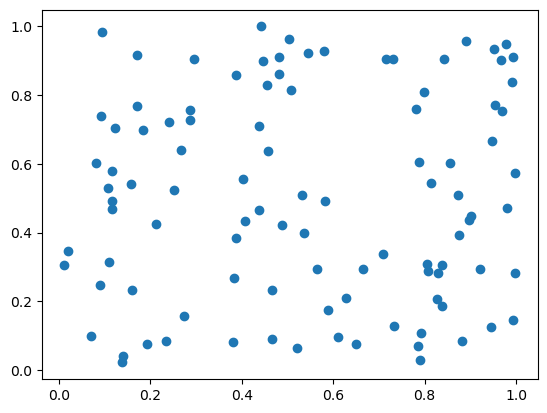

In [3]:
points = uniform(100)
plt.scatter(*points.T)

In [6]:
# make grid
L = 10

pos = np.linspace(0, 1, L, endpoint=False)
pos += 0.5 * (pos[1] - pos[0])
p = np.reshape(np.meshgrid(pos, pos), [2, -1]).T

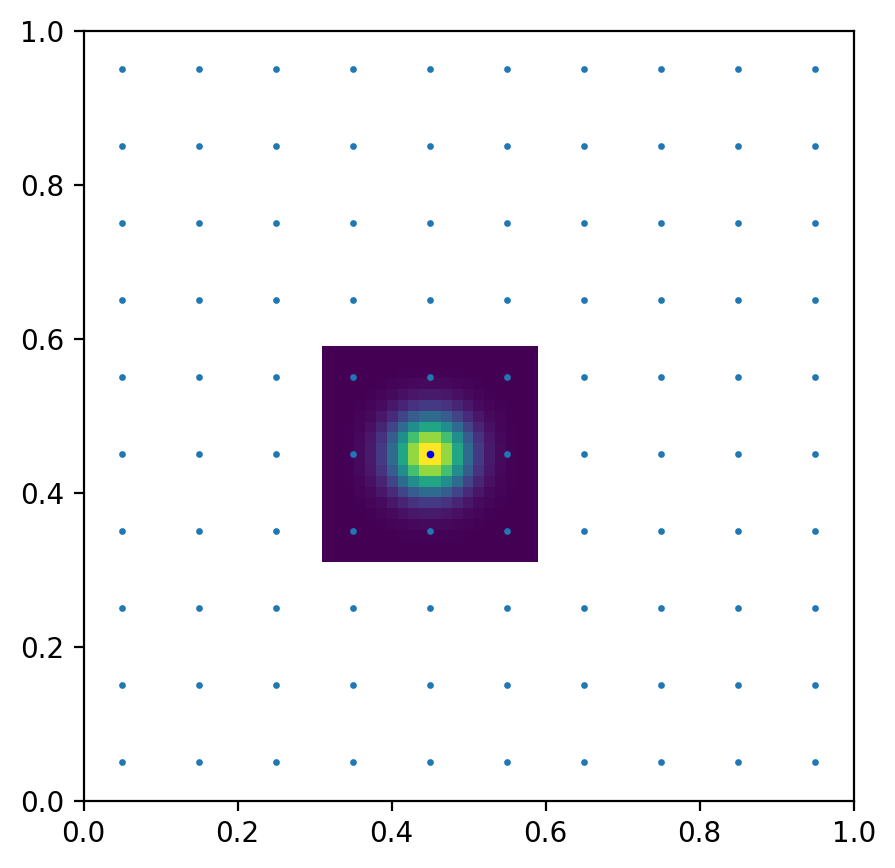

In [ ]:
sigma = 1 / 30 + 0.0001  # how far is each point allowed to move
kappa = sigma * 0  # lengthscale of how close you can get to each other vertex
beta = 1  # large beta forbids the system from choosing unlikely points
resolution = 20  # how finely sampled is the area to move to

# choose the point to move
d_from_center = p - 0.5
central_point = np.argmin(np.sum((p - 0.5) ** 2, axis=1))

_ = move_point(
    p,
    central_point,
    sigma,
    kappa,
    beta=beta,
    resolution=resolution,
    debug_plot=True,
)

100%|██████████| 10/10 [00:00<00:00, 14.87it/s]


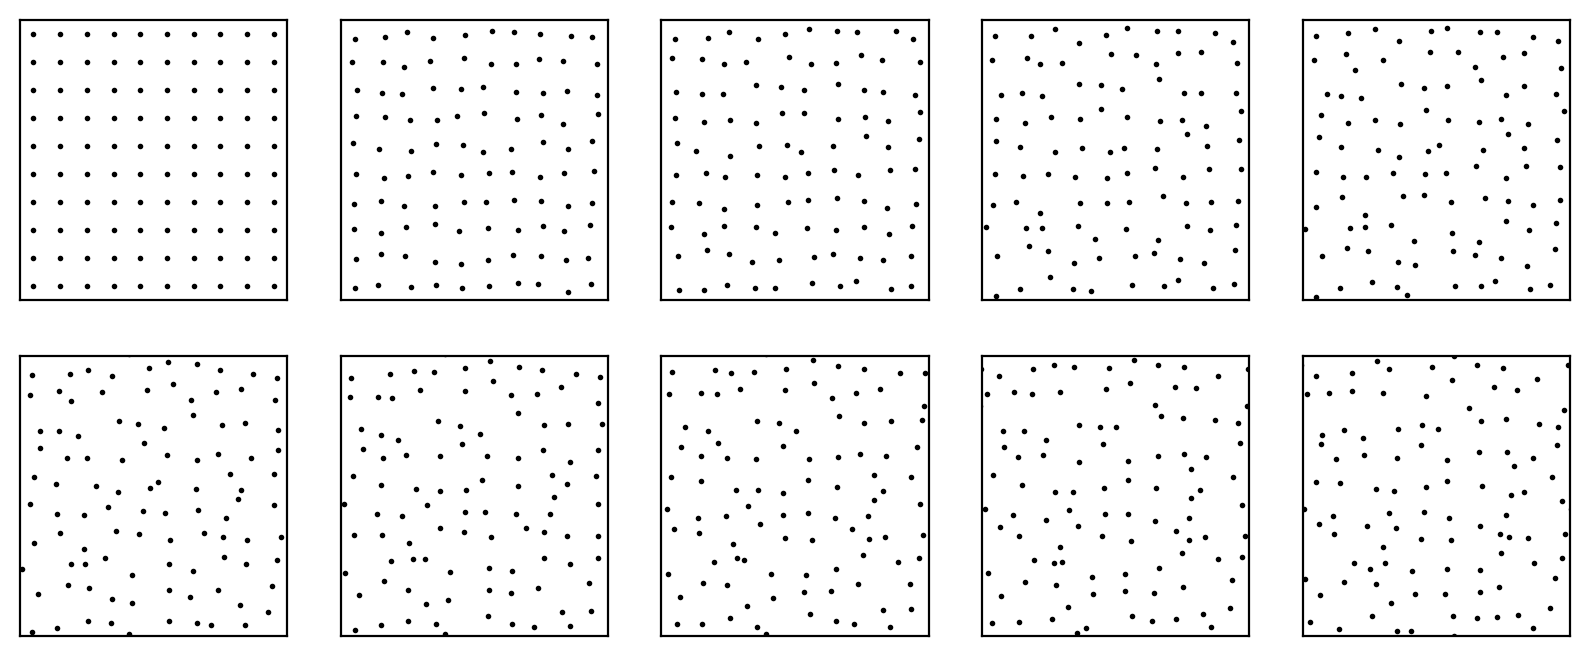

In [ ]:
n_steps = 10

fig, ax = plt.subplots(n_steps // 5, 5, figsize=(10, 2 * n_steps // 5), dpi=200)
ax = ax.flatten()

sigma = 0.02
kappa = sigma
beta = 6

p_new = p.copy()
for a in tqdm(ax):
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    s = 1
    a.scatter(*p_new.T, s=s, c="k")
    a.scatter(*(p_new + (0, 1)).T, s=s, c="k")
    a.scatter(*(p_new + (1, 0)).T, s=s, c="k")
    a.scatter(*(p_new + (0, -1)).T, s=s, c="k")
    a.scatter(*(p_new + (-1, 0)).T, s=s, c="k")

    p_new = move_all_points(p_new, sigma, kappa, beta, resolution=30)